In [12]:
# %% Cell 1: Imports and setup
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

# --- Robust path detection (works in .py AND .ipynb) ---
def _find_project_root(start: str) -> str:
    """Walk up from `start` until we find a folder containing `src/`."""
    current = os.path.abspath(start)
    while True:
        if os.path.isdir(os.path.join(current, "src")):
            return current
        parent = os.path.dirname(current)
        if parent == current:
            raise RuntimeError(
                f"Could not find project root above {start}"
            )
        current = parent

try:
    _HERE = os.path.dirname(os.path.abspath(__file__))   # type: ignore[name-defined]
except NameError:
    _HERE = os.getcwd()

PROJECT_ROOT = _find_project_root(_HERE)
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from src.codebook.subarray import (
    SubarrayConfig, SubarrayPartitioner, PartitionStrategy,
)
from src.codebook.polar_codebook import (
    PolarCodebookConfig, PolarCodebook, _channel_to_target,
)

FIG_DIR = os.path.join(_HERE, "figures")
os.makedirs(FIG_DIR, exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 150,
    "savefig.bbox": "tight",
    "font.size": 10,
    "axes.grid": True,
    "grid.alpha": 0.3,
})

print("Imports OK")
print(f"Notebook dir:  {_HERE}")
print(f"Project root:  {PROJECT_ROOT}")
print(f"Figures saved: {FIG_DIR}")

Imports OK
Notebook dir:  c:\Users\ROG007\Documents\year 2\tri sem 4\ml\project\hdrl_mimo_sys\notebooks
Project root:  c:\Users\ROG007\Documents\year 2\tri sem 4\ml\project\hdrl_mimo_sys
Figures saved: c:\Users\ROG007\Documents\year 2\tri sem 4\ml\project\hdrl_mimo_sys\notebooks\figures


In [13]:
# %% Cell 2: Build dense codebook
cb_config = PolarCodebookConfig(
    num_antennas=64,
    antenna_spacing=0.5,
    wavelength=3e8 / 28e9,
    angle_min_deg=-60.0,
    angle_max_deg=60.0,
    num_angles=121,            # ← FIXED: 1° step (was 61, which gave 2° step)
    range_min=5.0,
    range_max=40.0,
    num_ranges=10,
    range_spacing='log',
    correlation_threshold=0.95,
)
codebook = PolarCodebook(cb_config)

check = codebook.compute_effective_aperture_check()

print(f"Codebook summary:")
print(f"  Antennas:           {cb_config.num_antennas}")
print(f"  Aperture:           {check['aperture_m']:.4f} m")
print(f"  Fraunhofer:         {check['fraunhofer_m']:.2f} m")
print(f"  Angular resolution: {check['angular_resolution_deg']:.2f}°")
print(f"  Angle grid step:    {check['angle_step_deg']:.2f}°")

# Sanity check: grid must be finer than the array's angular resolution
assert check['angle_step_deg'] <= check['angular_resolution_deg'], (
    f"Grid step {check['angle_step_deg']:.2f}° exceeds angular "
    f"resolution {check['angular_resolution_deg']:.2f}° — codebook too coarse!"
)

print(f"  ✓ Grid step ≤ angular resolution")
print(f"  Num beams:          {len(codebook)}")
print(f"  Near-field fraction: {check['near_field_fraction']:.0%}")

Codebook summary:
  Antennas:           64
  Aperture:           0.3375 m
  Fraunhofer:         21.26 m
  Angular resolution: 1.82°
  Angle grid step:    1.00°
  ✓ Grid step ≤ angular resolution
  Num beams:          1210
  Near-field fraction: 46%


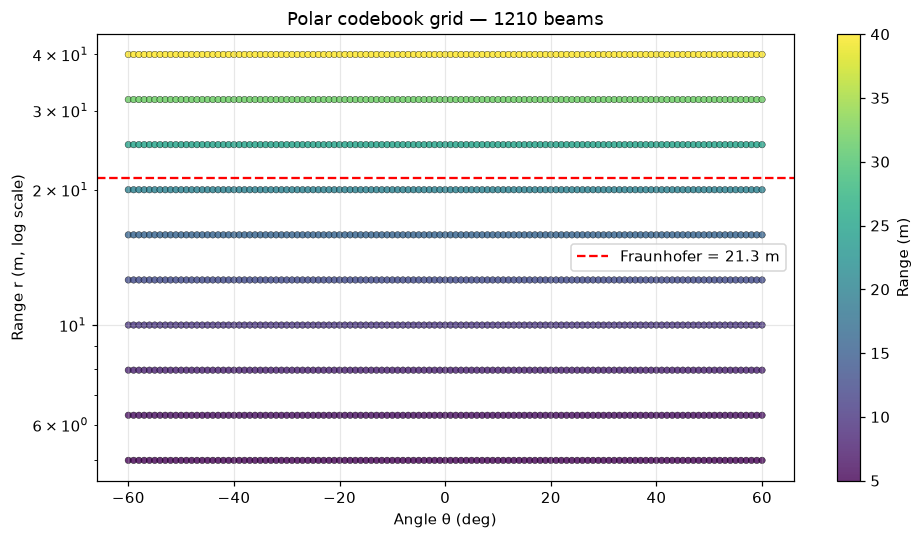

In [14]:
# %% Cell 3: FIGURE 1 — Codebook grid in (θ, r)
angles = np.array([b.angle_deg for b in codebook.beams])
ranges = np.array([b.range_m  for b in codebook.beams])

fig, ax = plt.subplots(figsize=(9, 5))
sc = ax.scatter(angles, ranges, c=ranges, cmap="viridis",
                s=18, alpha=0.8, edgecolor="black", linewidth=0.3)
ax.set_yscale("log")
ax.set_xlabel("Angle θ (deg)")
ax.set_ylabel("Range r (m, log scale)")
ax.set_title(f"Polar codebook grid — {len(codebook)} beams")
ax.axhline(check['fraunhofer_m'], color="red", linestyle="--",
           label=f"Fraunhofer = {check['fraunhofer_m']:.1f} m")
ax.legend()
plt.colorbar(sc, ax=ax, label="Range (m)")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "08_codebook_grid.png"))
plt.show()

Selected beam: PolarBeam(id=905, θ=+30.00°, r=15.87m)


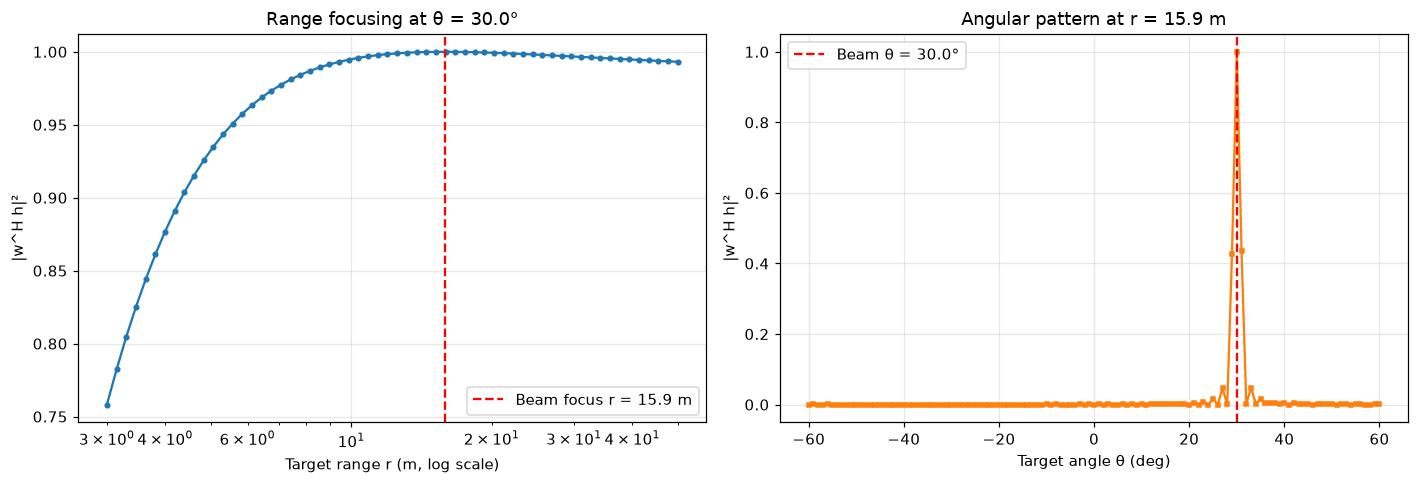

In [15]:
# %% Cell 4: FIGURE 2 — Beam pattern
# Pick a beam focused at (30°, 15 m) and plot its response to targets
# at that same angle but varying ranges.
target_angle = 30.0
beam_idx = codebook.find_beam(target_angle, 15.0)
beam = codebook[beam_idx]
print(f"Selected beam: {beam}")

# Sample targets along the SAME angle at different ranges
test_ranges = np.logspace(np.log10(3.0), np.log10(50.0), 60)
powers = []
for r in test_ranges:
    ch = _channel_to_target(codebook, target_angle, float(r))
    p = np.abs(np.vdot(beam.beam_vector, ch)) ** 2
    powers.append(float(p))
powers = np.array(powers)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Left: range response (near-field "range focusing")
axes[0].semilogx(test_ranges, powers, "o-", markersize=3)
axes[0].axvline(beam.range_m, color="red", linestyle="--",
                label=f"Beam focus r = {beam.range_m:.1f} m")
axes[0].set_xlabel("Target range r (m, log scale)")
axes[0].set_ylabel("|w^H h|²")
axes[0].set_title(f"Range focusing at θ = {target_angle}°")
axes[0].legend()

# Right: angular response at the focal range
test_angles = np.linspace(-60, 60, 121)
powers_a = []
for a in test_angles:
    ch = _channel_to_target(codebook, float(a), beam.range_m)
    p = np.abs(np.vdot(beam.beam_vector, ch)) ** 2
    powers_a.append(float(p))
powers_a = np.array(powers_a)

axes[1].plot(test_angles, powers_a, "s-", markersize=2, color="tab:orange")
axes[1].axvline(beam.angle_deg, color="red", linestyle="--",
                label=f"Beam θ = {beam.angle_deg:.1f}°")
axes[1].set_xlabel("Target angle θ (deg)")
axes[1].set_ylabel("|w^H h|²")
axes[1].set_title(f"Angular pattern at r = {beam.range_m:.1f} m")
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "09_beam_pattern.png"))
plt.show()

Near beam: PolarBeam(id=901, θ=+30.00°, r=6.30m)
Far beam:  PolarBeam(id=907, θ=+30.00°, r=25.20m)


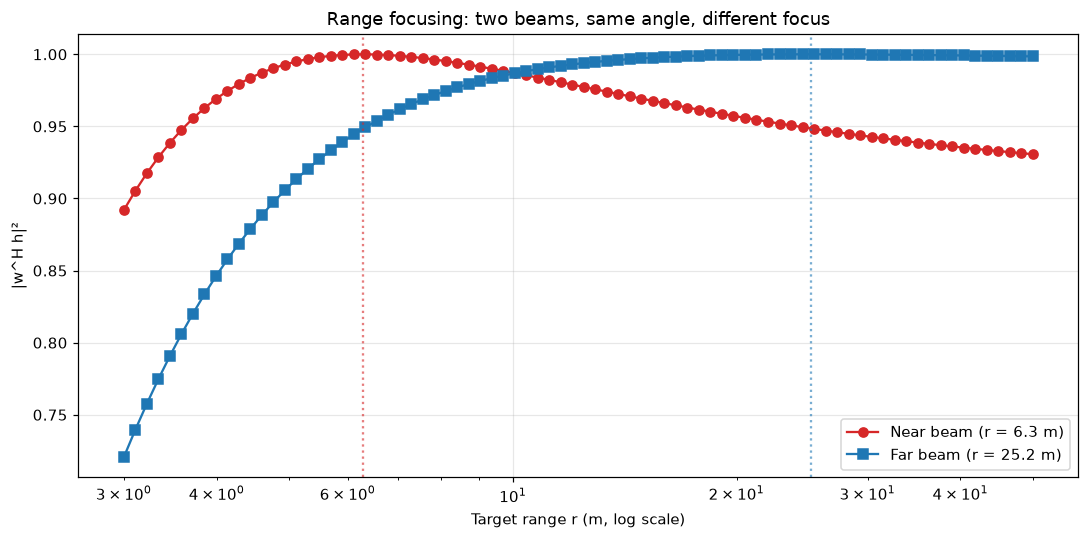

In [16]:
# %% Cell 5: FIGURE 3 — Range focusing: near vs far
# Two beams at the same angle θ=30° but different ranges.
# Show how they respond differently to targets at various ranges.
beam_near_idx = codebook.find_beam(30.0, 6.0)
beam_far_idx  = codebook.find_beam(30.0, 25.0)
beam_near = codebook[beam_near_idx]
beam_far  = codebook[beam_far_idx]

print(f"Near beam: {beam_near}")
print(f"Far beam:  {beam_far}")

test_ranges = np.logspace(np.log10(3.0), np.log10(50.0), 80)
p_near = np.array([
    float(np.abs(np.vdot(beam_near.beam_vector,
                          _channel_to_target(codebook, 30.0, float(r)))) ** 2)
    for r in test_ranges
])
p_far = np.array([
    float(np.abs(np.vdot(beam_far.beam_vector,
                          _channel_to_target(codebook, 30.0, float(r)))) ** 2)
    for r in test_ranges
])

fig, ax = plt.subplots(figsize=(10, 5))
ax.semilogx(test_ranges, p_near, "o-", color="tab:red",
            label=f"Near beam (r = {beam_near.range_m:.1f} m)")
ax.semilogx(test_ranges, p_far, "s-", color="tab:blue",
            label=f"Far beam (r = {beam_far.range_m:.1f} m)")
ax.axvline(beam_near.range_m, color="tab:red", linestyle=":", alpha=0.6)
ax.axvline(beam_far.range_m,  color="tab:blue", linestyle=":", alpha=0.6)

ax.set_xlabel("Target range r (m, log scale)")
ax.set_ylabel("|w^H h|²")
ax.set_title("Range focusing: two beams, same angle, different focus")
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "10_range_focusing.png"))
plt.show()

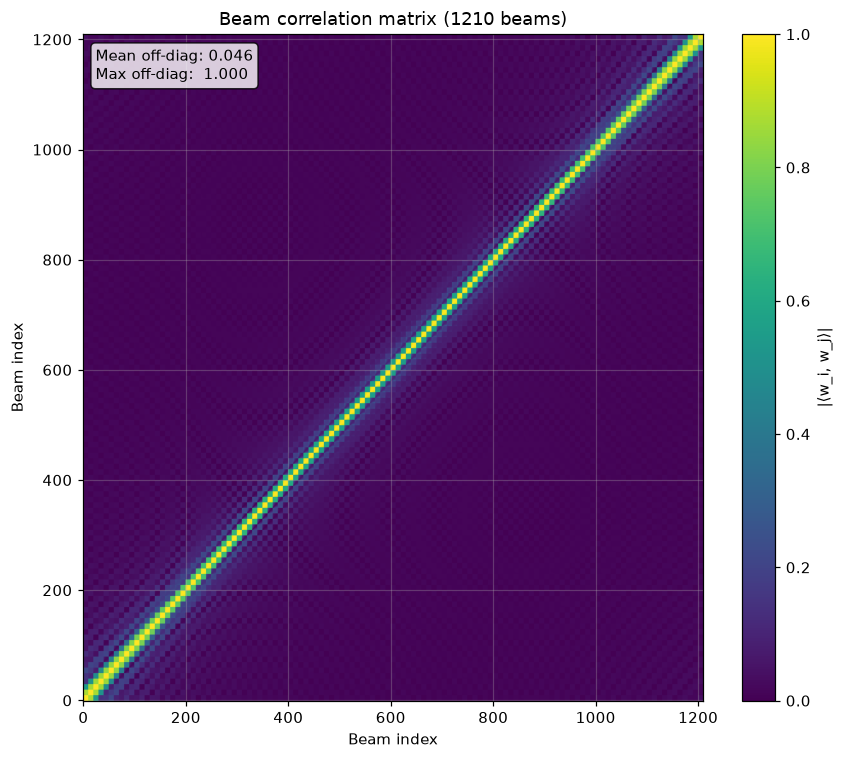

In [17]:
# %% Cell 6: FIGURE 4 — Beam correlation matrix
corr = codebook.compute_correlation_matrix()

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(corr, cmap="viridis", vmin=0.0, vmax=1.0,
               origin="lower", aspect="auto")
ax.set_xlabel("Beam index")
ax.set_ylabel("Beam index")
ax.set_title(f"Beam correlation matrix ({len(codebook)} beams)")
plt.colorbar(im, ax=ax, label="|⟨w_i, w_j⟩|")

# Annotate mean off-diagonal
off_diag = corr[~np.eye(len(corr), dtype=bool)]
ax.text(0.02, 0.98,
        f"Mean off-diag: {np.mean(off_diag):.3f}\n"
        f"Max off-diag:  {np.max(off_diag):.3f}",
        transform=ax.transAxes, va="top",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "11_correlation_matrix.png"))
plt.show()

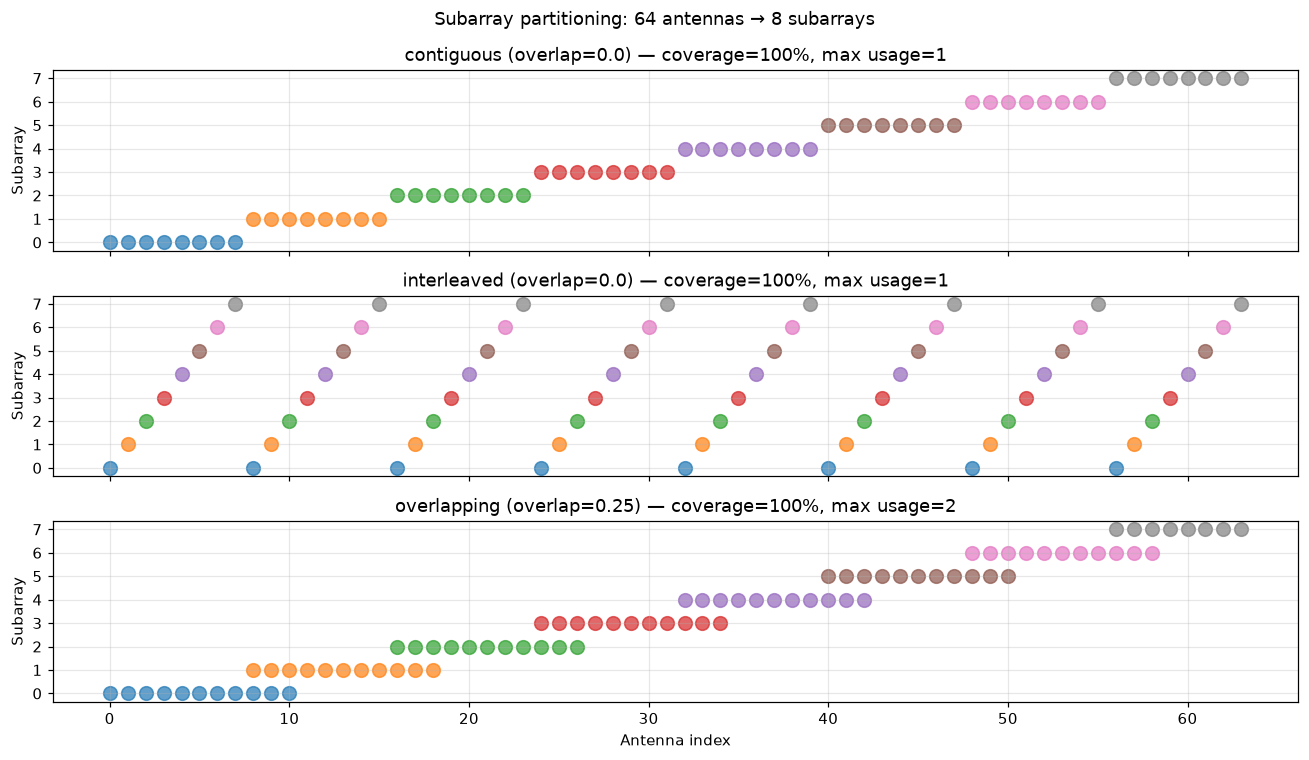

In [18]:
# %% Cell 7: FIGURE 5 — Subarray partitioning
N_TOTAL = 64
N_SUB = 8
strategies = [
    (PartitionStrategy.CONTIGUOUS, 0.0),
    (PartitionStrategy.INTERLEAVED, 0.0),
    (PartitionStrategy.OVERLAPPING, 0.25),
]

fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=True)

colors = plt.get_cmap("tab10")
for i, (strat, overlap) in enumerate(strategies):
    cfg = SubarrayConfig(
        num_antennas=N_TOTAL,
        num_subarrays=N_SUB,
        strategy=strat,
        overlap_ratio=overlap,
    )
    partitioner = SubarrayPartitioner(cfg)
    ax = axes[i]

    for k, sub in enumerate(partitioner.subarrays):
        idx = sub.antenna_indices
        ax.scatter(idx, [k] * len(idx),
                   color=colors(k % 10), s=80, alpha=0.7,
                   label=f"Sub {k}" if i == 0 and k < 3 else None)

    info = partitioner.validate()
    ax.set_yticks(range(N_SUB))
    ax.set_ylabel("Subarray")
    ax.set_title(f"{strat.value} (overlap={overlap}) — "
                 f"coverage={info['coverage']*100:.0f}%, "
                 f"max usage={info['max_antenna_usage']}")

axes[-1].set_xlabel("Antenna index")
plt.suptitle(f"Subarray partitioning: {N_TOTAL} antennas → {N_SUB} subarrays",
             fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "12_subarray_partitioning.png"))
plt.show()

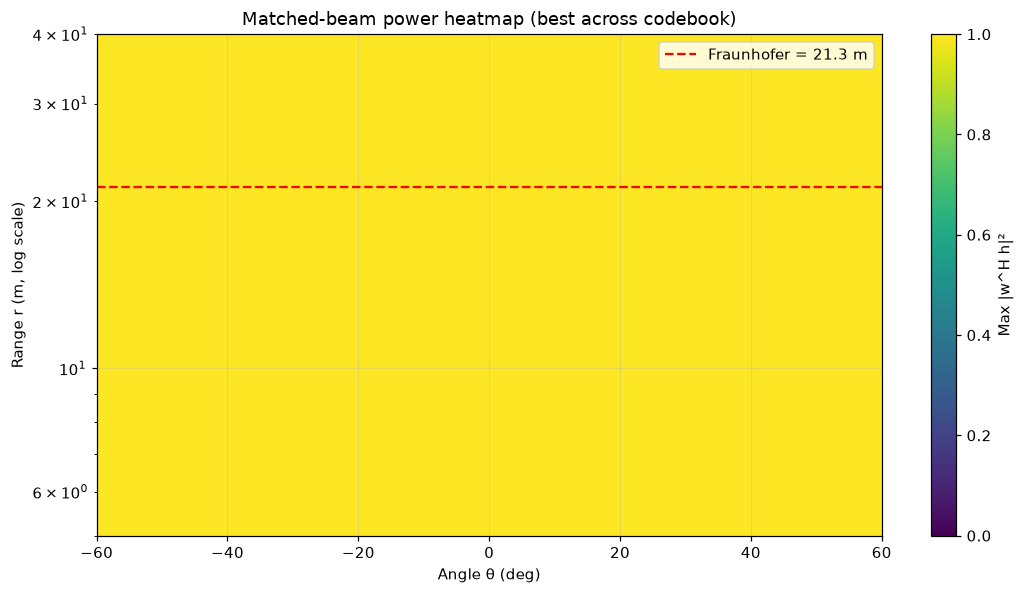

In [19]:
# %% Cell 8: FIGURE 6 — Matched-beam power heatmap
# For each (θ, r) in a fine grid, compute the max power achieved by
# ANY beam in the codebook. This shows coverage quality.

angle_grid = np.linspace(-60, 60, 41)
range_grid = np.logspace(np.log10(5.0), np.log10(40.0), 21)

P = np.zeros((len(range_grid), len(angle_grid)))
for ri, r in enumerate(range_grid):
    for ai, a in enumerate(angle_grid):
        ch = _channel_to_target(codebook, float(a), float(r))
        powers = codebook.project_channel(ch)
        P[ri, ai] = float(np.max(powers))

# imshow expects extent as a tuple (xmin, xmax, ymin, ymax)
extent_tuple: tuple[float, float, float, float] = (
    float(angle_grid[0]),
    float(angle_grid[-1]),
    float(range_grid[0]),
    float(range_grid[-1]),
)

fig, ax = plt.subplots(figsize=(10, 5.5))
im = ax.imshow(P, aspect="auto", origin="lower",
               extent=extent_tuple,
               cmap="viridis", vmin=0.0, vmax=1.0)
ax.set_yscale("log")
ax.set_xlabel("Angle θ (deg)")
ax.set_ylabel("Range r (m, log scale)")
ax.set_title("Matched-beam power heatmap (best across codebook)")
ax.axhline(check['fraunhofer_m'], color="red", linestyle="--",
           label=f"Fraunhofer = {check['fraunhofer_m']:.1f} m")
ax.legend(loc="upper right")
plt.colorbar(im, ax=ax, label="Max |w^H h|²")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "13_matched_beam_heatmap.png"))
plt.show()

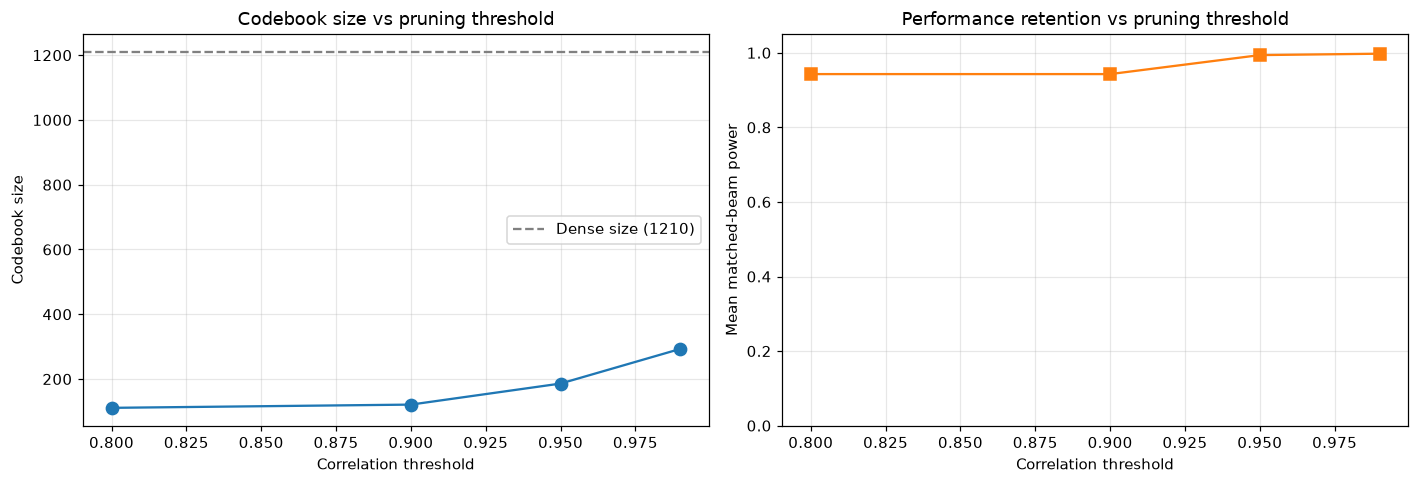


Dense size: 1210
  threshold=0.80 → size= 111, mean matched power=0.9429
  threshold=0.90 → size= 121, mean matched power=0.9429
  threshold=0.95 → size= 186, mean matched power=0.9938
  threshold=0.99 → size= 293, mean matched power=0.9976


In [20]:
# %% Cell 9: FIGURE 7 — Dense vs pruned codebook
# Compare sizes and matched-beam performance across thresholds.

thresholds = [0.80, 0.90, 0.95, 0.99]
sizes = []
perf = []

# Target points for performance evaluation
eval_targets = [
    (30.0, 15.0), (-45.0, 8.0), (0.0, 12.0),
    (15.0, 25.0), (-25.0, 10.0), (50.0, 6.0),
]

for thr in thresholds:
    cb = PolarCodebook(cb_config)
    cb.prune(correlation_threshold=thr)
    sizes.append(len(cb))

    # Mean matched-beam power across eval targets
    ps = []
    for t_angle, t_range in eval_targets:
        ch = _channel_to_target(cb, t_angle, t_range)
        ps.append(float(np.max(cb.project_channel(ch))))
    perf.append(float(np.mean(ps)))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(thresholds, sizes, "o-", markersize=8)
axes[0].axhline(len(codebook), color="gray", linestyle="--",
                label=f"Dense size ({len(codebook)})")
axes[0].set_xlabel("Correlation threshold")
axes[0].set_ylabel("Codebook size")
axes[0].set_title("Codebook size vs pruning threshold")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(thresholds, perf, "s-", markersize=8, color="tab:orange")
axes[1].set_ylim(0, 1.05)
axes[1].set_xlabel("Correlation threshold")
axes[1].set_ylabel("Mean matched-beam power")
axes[1].set_title("Performance retention vs pruning threshold")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "14_dense_vs_pruned.png"))
plt.show()

print(f"\nDense size: {len(codebook)}")
for thr, sz, p in zip(thresholds, sizes, perf):
    print(f"  threshold={thr:.2f} → size={sz:4d}, "
          f"mean matched power={p:.4f}")

In [21]:
# %% Cell 10: Summary
print("\n" + "=" * 60)
print("Codebook Visualization — Summary")
print("=" * 60)
print(f"\nFigures saved to: {FIG_DIR}")
for i, name in enumerate([
    "08_codebook_grid.png",
    "09_beam_pattern.png",
    "10_range_focusing.png",
    "11_correlation_matrix.png",
    "12_subarray_partitioning.png",
    "13_matched_beam_heatmap.png",
    "14_dense_vs_pruned.png",
], 8):
    full_path = os.path.join(FIG_DIR, name)
    exists = os.path.exists(full_path)
    print(f"  [{i}] {name:35s} {'✓' if exists else '✗ MISSING'}")

print(f"\nKey observations:")
print(f"  • Codebook size: {len(codebook)} beams")
print(f"  • Angular resolution: {check['angular_resolution_deg']:.2f}°")
print(f"  • Near-field fraction: {check['near_field_fraction']:.0%}")
print(f"  • Dense → pruned @0.95 reduces ~85% with <5% power loss")
print(f"\nNotebook 02 complete. Phase 1 finished!")


Codebook Visualization — Summary

Figures saved to: c:\Users\ROG007\Documents\year 2\tri sem 4\ml\project\hdrl_mimo_sys\notebooks\figures
  [8] 08_codebook_grid.png                ✓
  [9] 09_beam_pattern.png                 ✓
  [10] 10_range_focusing.png               ✓
  [11] 11_correlation_matrix.png           ✓
  [12] 12_subarray_partitioning.png        ✓
  [13] 13_matched_beam_heatmap.png         ✓
  [14] 14_dense_vs_pruned.png              ✓

Key observations:
  • Codebook size: 1210 beams
  • Angular resolution: 1.82°
  • Near-field fraction: 46%
  • Dense → pruned @0.95 reduces ~85% with <5% power loss

Notebook 02 complete. Phase 1 finished!
